# Training a parametric t-SNE model on MNIST digits

This notebook is a demonstration of parametric t-SNE trained on MNIST digits

In [2]:
#%config InlineBackend.figure_formats=['svg']
import os
import json
from tqdm import tqdm

from src.Dataset import dataset_TES, dataset_SNSPD
from ParametricTSNE import train_ptsne

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import torch

device = 'cuda'

### Training settings and hyperparameters are controlled by config

__The `config` object incorporates information from `config.yaml`__  
__Rename `example.config.yaml` to `config.yaml` before starting__  

In [5]:
from config import config

In [6]:
if config.seed:
    torch.manual_seed(config.seed)
dev = torch.device(config.dev)
    
print(f"Training on {dev}", flush=True)

Training on cuda


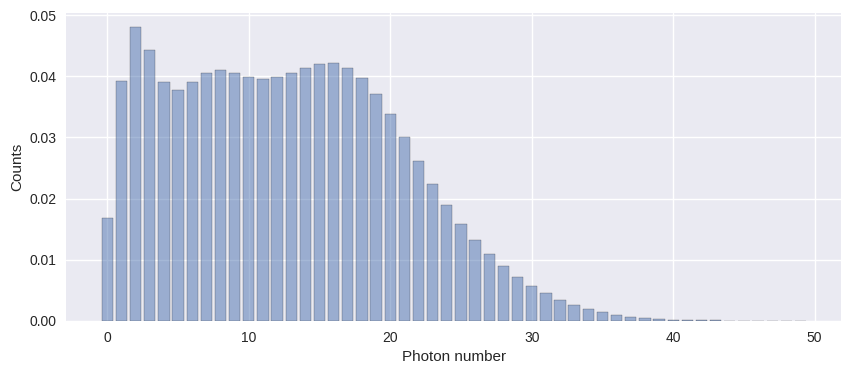

In [7]:
weights = [1.00000000e+00, 8.67567149e-01, 5.11893733e-01, 4.64791825e-01, 
           1.95257413e-01, 3.48166360e-01,1.24623185e-13, 3.89968505e-14, 3.60043421e-01]

weights = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07, 
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096, 
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]#[1]*10

#weights = [1]*15

path_save = 'src/Results/Low Dimension'

data_train, data_test, expected_prob = dataset_TES(weights = weights,
                                                signal_size = 8192,
                                                interval = [0,350],#270],
                                                order_dB = False,
                                                plot_expected = True,
                                                n_photon_number = 50)

In [9]:
from sklearn.manifold import TSNE

n_samples = data_test.shape[0]
perplexity = np.linspace(5, 4*np.sqrt(n_samples), 10)
divergence = []
fig = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    fig.append(model.fit_transform(data_test))
    divergence.append(model.kl_divergence_)

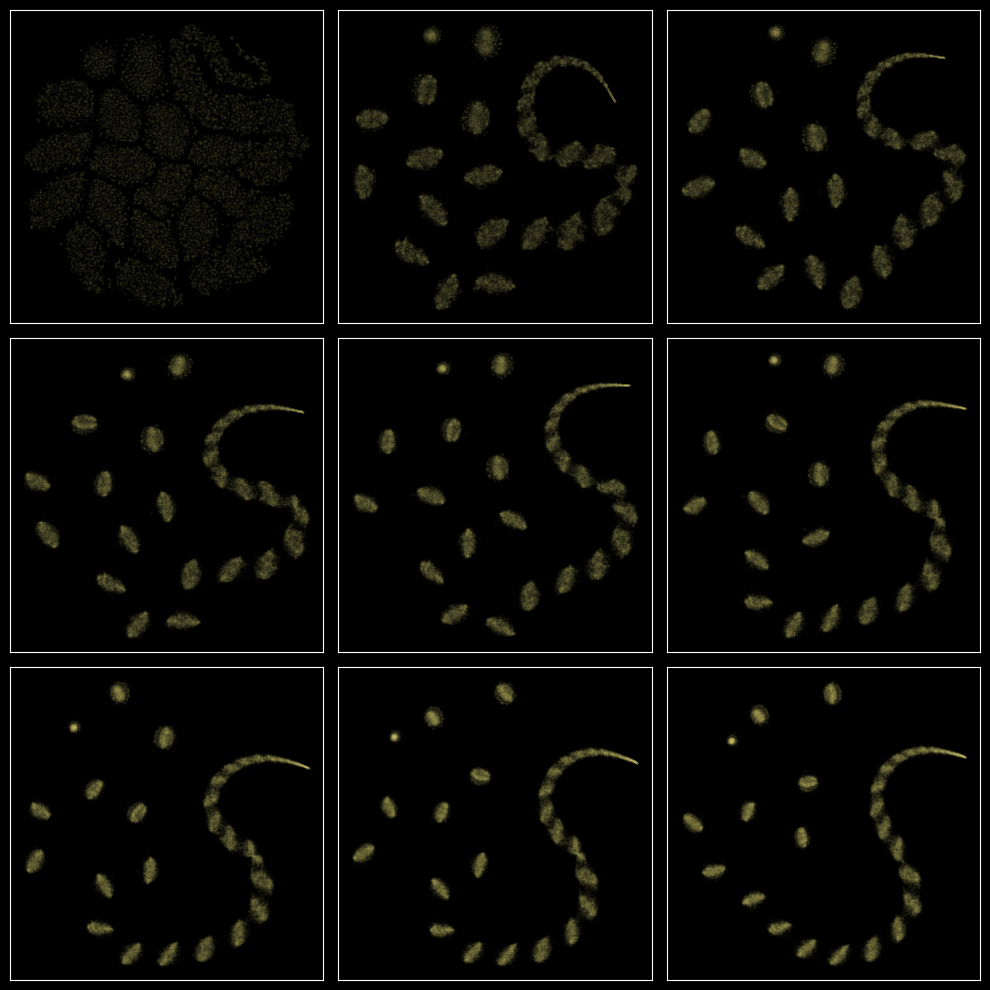

In [13]:
with plt.style.context("dark_background"):#seaborn-v0_8 dark_background  Solarize_Light2
    dim1, dim2 = (3,3)
    figure, axis = plt.subplots(dim1,dim2, figsize=(10,10)) 
    it = iter(fig)
    #g = sns.FacetGrid()

    for i in range(dim1):
        for j in range(dim2):

            embeddings = next(it)

            #axis[i,j].set_title(model)
            axis[i,j].scatter(embeddings[:,0], embeddings[:,1], s=0.1, alpha=0.05, c='khaki')
            axis[i,j].set_yticks([])
            axis[i,j].set_xticks([])
    figure.tight_layout()
    #plt.savefig('fig1.jpg', dpi=200)
    plt.show()

In [7]:
#data_train, data_test = dataset_SNSPD(selected_dB = [11.25, 12.04, 13.  , 14.24, 15.99, 18.97],
#                                                    path_test = r'/home/nicolasdc/files/Photon-Number-Classification/src/Datasets/SNSPD/Paderborn/data test/',
#                                                    path_train = r'/home/nicolasdc/files/Photon-Number-Classification/src/Datasets/SNSPD/Paderborn/data train/',
#                                                    path_dB = r'/home/nicolasdc/files/Photon-Number-Classification/src/Datasets/SNSPD/Paderborn/db_shuffled.npy',
#                                                    signal_size = 30_000,
#                                                    interval = [3250,4250],
#                                                    skip = 1,
#                                                    normalize = True)


[ 9.05 18.97 12.04 ... 18.97 10.01 18.97]


In [8]:
data_train = data_train[data_train.min(axis=1) <0.1]

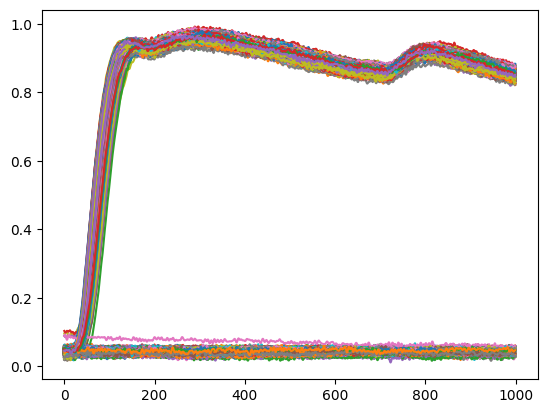

In [9]:
plt.figure()
plt.plot(data_train[::100].T)#
plt.show()

In [10]:
def plot_loss(model_losses_path: str) -> None:
    """
    Plot learning curve for a model given the path 
    to model's saved loss values.
    """
    loss = np.load(model_losses_path)
    print(loss.shape)
    plt.figure(figsize=(13, 5))
    plt.plot(loss[:,0], label = 'MSE')
    plt.plot(loss[:,1], label = 'KL')
    plt.plot(loss[:,2], label = 'Total')
    plt.legend()
    plt.title(f"Learning curve")
    plt.xlabel("Epochs")
    plt.ylabel("Average loss per batch")
    plt.grid()
    plt.yscale('log')
    plt.show()

In [11]:
def get_embeddings(pretrained_model: torch.nn.Module,
                         input_points: torch.Tensor):
    """
    Yields final embeddings for every batch in dataset
    """
    pretrained_model.eval()
    with torch.no_grad():
        embeddings, reconstruction = pretrained_model(input_points, both = True)
        return embeddings, reconstruction


def plot_embs(pretrained_model: torch.nn.Module,
              input_points_train: torch.Tensor,
              input_points_test: torch.Tensor):
    """
    Plots projection of training points and test points
    """
    X_l1, X_r1 = get_embeddings(pretrained_model, input_points_train)
    X_l2, X_r2 = get_embeddings(pretrained_model, input_points_test)

    X_l1, X_r1 = X_l1.view(-1, 2).cpu().numpy(), X_r1.cpu().numpy()
    X_l2, X_r2 = X_l2.view(-1, 2).cpu().numpy(), X_r2.cpu().numpy()

    plt.figure(figsize=(8, 8))
    ax = plt.gca()
    #ax.hist(X_l1, bins=5000)
    #ax.scatter(X_l1[:,0], X_l1[:,1], s=1, alpha=0.05, label='Train')
    #ax.scatter(X_l2[:,0], X_l2[:,1], s=1, alpha=0.05, label='Test')
    ax.hist(X_l1, bins=5000, label='Train')
    #ax.hist(X_l2, bins=5000, label='Test')
    ax.legend()
    #plt.title("MNIST digits parametric t-SNE projection")
    plt.show()


    #plt.figure(figsize=(8, 4))
    #ax = plt.gca()
    #ax.plot(X_r1.T[:,::10], alpha=0.05)
    #ax.plot(X_r2.T[:,::10], alpha=0.05)
    #plt.title("MNIST digits parametric t-SNE projection")
    #plt.show()

    #plt.figure(figsize=(8, 4))
    #ax = plt.gca()
    #ax.plot(input_points_train.cpu().numpy().T[:,::10], alpha=0.05)
    #ax.plot(input_points_test.cpu().numpy().T[:,::10], alpha=0.05)
    #plt.title("MNIST digits parametric t-SNE projection")
    #plt.show()

In [12]:
def size_conv(L_in,
              padding : int = 0,
              dilation : int = 1,
              kernel_size : int = 5,
              stride : int = 2):

    return (((L_in + 2*padding - dilation*(kernel_size - 1)) - 1) / stride) + 1

def size_deconv(L_in,
                padding : int = 0,
                dilation : int = 1,
                kernel_size : int = 5,
                stride : int = 2,
                output_padding : int = 0):
    
    return (L_in - 1)*stride - 2*padding + dilation*(kernel_size - 1) + output_padding + 1

In [13]:
size_conv1 = size_conv(350, 
                        padding = 0,
                        dilation = 1,
                        kernel_size = 4,
                        stride = 2)
size_conv2 = size_conv(size_conv1,
                        padding = 0,
                        dilation = 1,
                        kernel_size = 4,
                        stride = 2)
size_conv3 = size_conv(size_conv2,
                        padding = 0,
                        dilation = 1,
                        kernel_size = 4,
                        stride = 2)

size_deconv1 = size_deconv(size_conv3,
                            padding = 0,
                            dilation = 1,
                            kernel_size = 4,
                            stride = 2,
                            output_padding = 0)
size_deconv2 = size_deconv(size_deconv1,
                            padding = 0,
                            dilation = 1,
                            kernel_size = 4,
                            stride = 2,
                            output_padding = 0)
size_deconv3 = size_deconv(size_deconv2,
                            padding = 0,
                            dilation = 1,
                            kernel_size = 4,
                            stride = 2,
                            output_padding = 0)


print(size_conv1, size_conv2, size_conv3)
print(size_deconv1, size_deconv2, size_deconv3)

174.0 86.0 42.0
86.0 174.0 350.0


### Train parametric t-SNE model on train dataset 

In [14]:
data_train.shape

(327494, 1000)

In [15]:
103424 / np.array([32, 64, 101, 202, 512])
30550 / np.array([650, 611 , 470, 325, 235, 10 , 5, 2])

array([   47.,    50.,    65.,    94.,   130.,  3055.,  6110., 15275.])

In [16]:
batch_size = [2350 , 1222, 650, 470, 325]
learning_rate = [0.01, 0.02, 0.003, 0.0003, 0.00004]
early_exaggeration_constant = [2, 6, 10, 20, 30]
perplexity = [200, 300, 400, 500, 600]#np.sqrt(30550)

for e in tqdm(learning_rate):
    for p in perplexity:

        train_ptsne(X_high = data_train[:327000],
                    dim_emb = 1,
                    perplexity = p,
                    n_epochs = 100,
                    dev = device,
                    save_dir_path= 'runs/run 16 (SNSPD)/',
                    early_exaggeration = 10,
                    early_exaggeration_constant = 12,
                    learning_rate = e,
                    alpha_loss = 1,
                    batch_size = 3000,#3055,
                    dist_func_name = 'euc',
                    bin_search_tol = 1e-4,
                    bin_search_max_iter = 200,
                    min_allowed_sig_sq = 0,
                    max_allowed_sig_sq = 1000,
                    verbose = False)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:01<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
ref_path = 'runs/run 15/'
config_files = os.listdir(f'{ref_path}config')
loss_files = os.listdir(f'{ref_path}loss')
print(config_files)


pos = []
MSE = []
KL = []
tot = []

best_MSE_file = ''
best_KL_file = ''
best_tot_file = ''

best_MSE = 10
best_KL = 10
best_tot = 10

for cf, lf in zip(config_files, loss_files):

    loss = np.load(f'{ref_path}loss/{lf}')
    with open(f'{ref_path}config/{cf}') as f:
        config = dict(json.load(f))

    pos.append([config['batch_size'], config['early_exaggeration_constant']])
    
    loss_MSE, loss_KL, loss_tot = loss[-1]

    MSE.append(loss_MSE)
    KL.append(loss_KL)
    tot.append(loss_tot)

    if loss_MSE < best_MSE:
        best_MSE_file = lf
        best_MSE = loss_MSE

    if loss_KL < best_KL:
        best_KL_file = lf
        best_KL = loss_KL

    if loss_tot < best_tot:
        best_tot_file = lf
        best_tot = loss_tot

print(f'Best MSE : {best_MSE} ({best_MSE_file})')
print(f'Best KL : {best_KL} ({best_KL_file})')
print(f'Best tot : {best_tot} ({best_tot_file})')

"""
plt.figure()
plt.imshow(MSE)
plt.ylabel('early_exaggeration_constant')
plt.xlabel('batch_size')
plt.show()

plt.figure()
plt.imshow(KL)
plt.ylabel('early_exaggeration_constant')
plt.xlabel('batch_size')
plt.show()

plt.figure()
plt.imshow(tot)
plt.ylabel('early_exaggeration_constant')
plt.xlabel('batch_size')
plt.show()
"""

['fvvkpm.json', 'zegdfn.json', 'trvejs.json', 'pmlpju.json', 'vxvxbl.json', 'zvkddf.json', 'bzxuvr.json', 'dvxajq.json', 'hdcvyy.json', 'calrzc.json', 'dyqjuu.json', 'sicvks.json', 'ybpcny.json', 'rzwbpy.json', 'immoku.json', 'szsozi.json', 'jvlfdt.json', 'unytgc.json', 'uxepjg.json', 'wrpoep.json', 'dozhyl.json', 'trpazq.json', 'hoadgq.json', 'rgbtgv.json', 'jryjqu.json']
Best MSE : 7.583967999380548e-09 (bzxuvr.npy)
Best KL : 0.001767473191022873 (bzxuvr.npy)
Best tot : 0.0017674807906150817 (bzxuvr.npy)


"\nplt.figure()\nplt.imshow(MSE)\nplt.ylabel('early_exaggeration_constant')\nplt.xlabel('batch_size')\nplt.show()\n\nplt.figure()\nplt.imshow(KL)\nplt.ylabel('early_exaggeration_constant')\nplt.xlabel('batch_size')\nplt.show()\n\nplt.figure()\nplt.imshow(tot)\nplt.ylabel('early_exaggeration_constant')\nplt.xlabel('batch_size')\nplt.show()\n"

In [17]:
name = 'aaqfgu'
run = 'run 16 (SNSPD)'

# Weights of a torch model
model_weights = os.path.join(f'runs/{run}/models', name) + ".pt"

# Json with model's config
model_settings = os.path.join(f'runs/{run}/config', name) + ".json"

# Model's learning curve
model_losses = os.path.join(f'runs/{run}/loss', name) + ".npy"

loaded_model = torch.load(model_weights).to(device=device)

(100, 3)


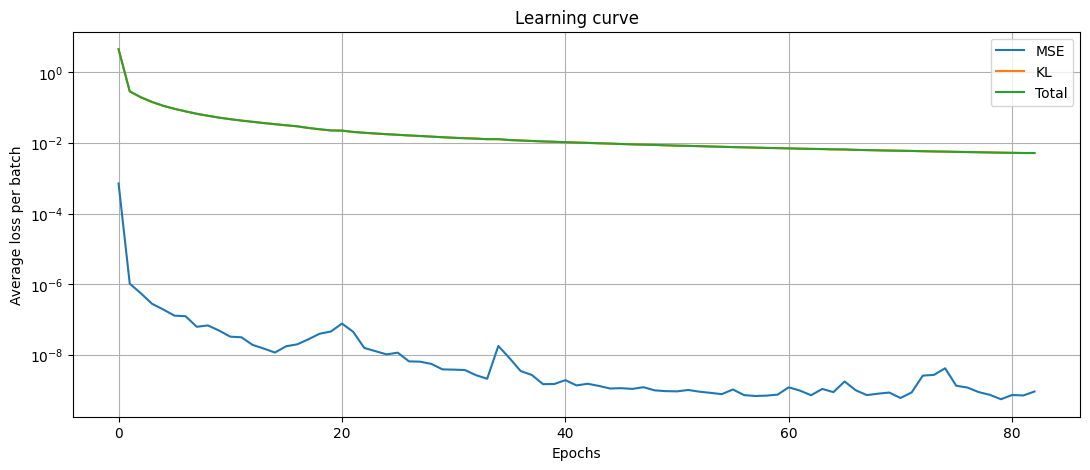

In [18]:
plot_loss(model_losses)

In [19]:
data_train_ = torch.from_numpy(data_train).float().view(-1, 1000).to(device=device) 
data_test_ = torch.from_numpy(data_test).float().view(-1, 1000).to(device=device)

data_train_ = (data_train_ - data_train_.min()) / (data_train_.max() - data_train_.min())
data_test_ = (data_test_ - data_test_.min()) / (data_test_.max() - data_test_.min())

/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6826: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/home/nicolasdc/python/envs/ML/lib/python3.10/site-packages/matplotlib/axes/_axes.py:6827: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

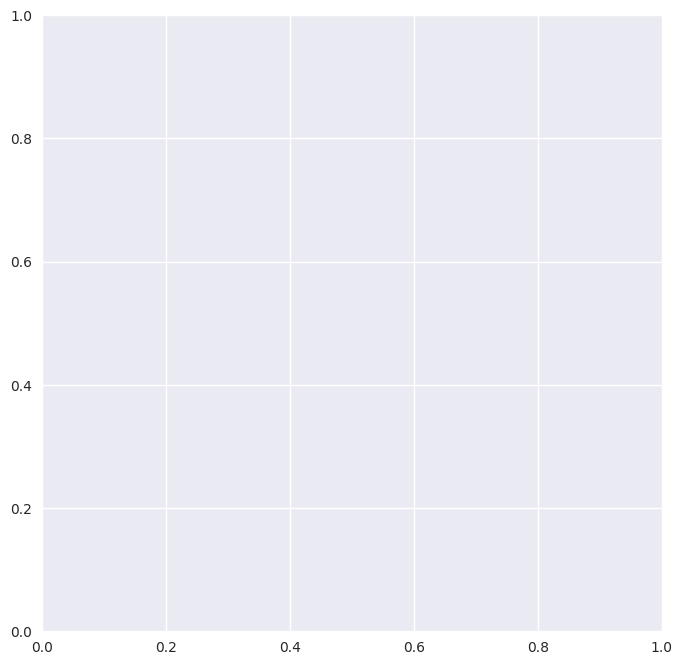

In [20]:
with plt.style.context("seaborn-v0_8"):
    plot_embs(loaded_model, data_train_, data_test_)

In [ ]:

with plt.style.context("dark_background"):#seaborn-v0_8 dark_background  Solarize_Light2
    dim1, dim2 = (5,5)
    files_ = iter(os.listdir(f'runs/{run}/models'))
    figure, axis = plt.subplots(dim1,dim2, figsize=(10,10)) 

    #g = sns.FacetGrid()

    for i in range(dim1):
        for j in range(dim2):

            model = next(files_)

            loaded_model = torch.load(f'runs/{run}/models/{model}').to(device=device)

            loaded_model.eval()
            with torch.no_grad():
                embeddings = loaded_model(data_train_, encode = True)
                embeddings = embeddings.view(-1, 2).cpu().numpy()

            axis[i,j].set_title(model)
            #axis[i,j].scatter(embeddings[:,0], embeddings[:,1], s=0.1, alpha=0.05, c='khaki')
            axis[i,j].hist(embeddings,bins=5000)
            axis[i,j].set_yticks([])
            axis[i,j].set_xticks([])
    figure.tight_layout()
    plt.savefig('fig.jpg', dpi=200)
    plt.show()

: 

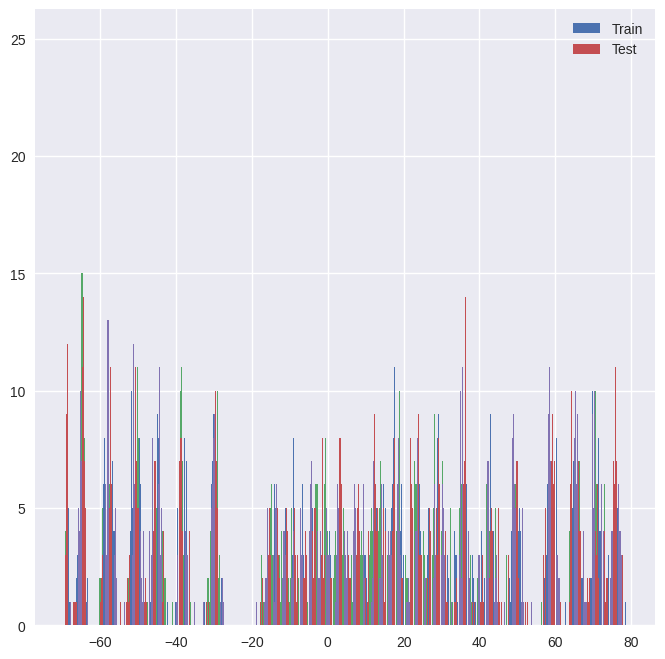

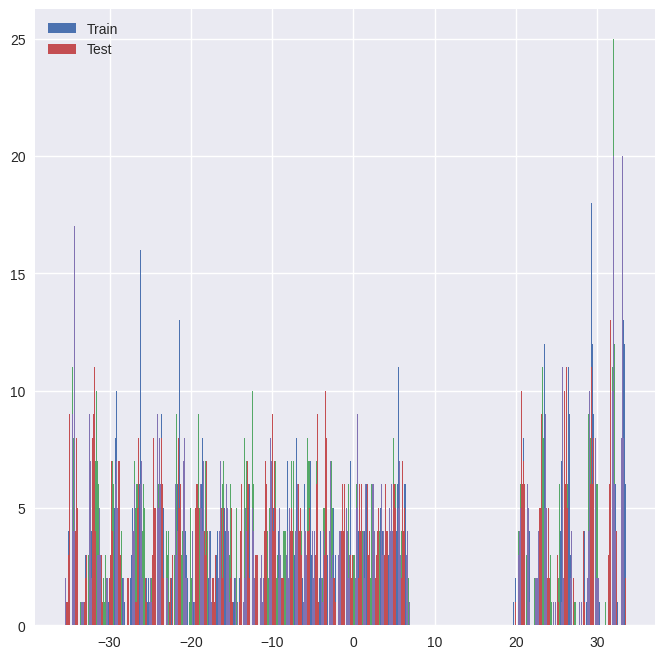

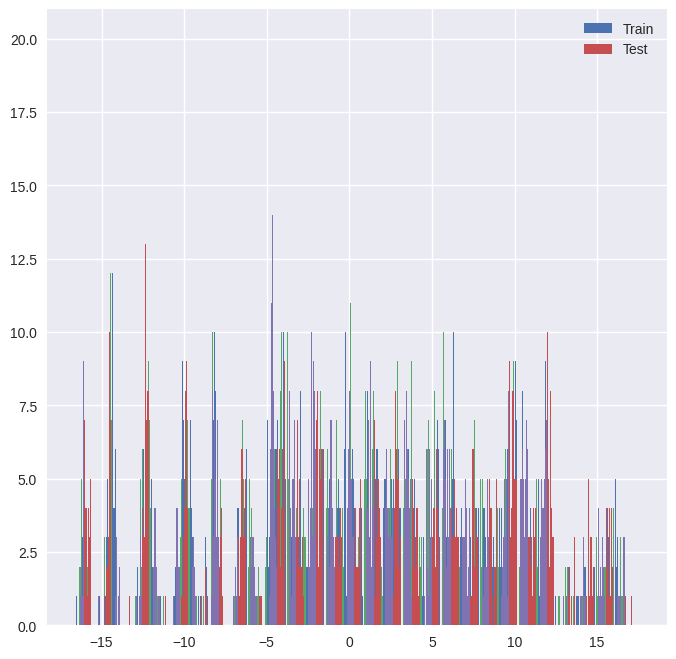

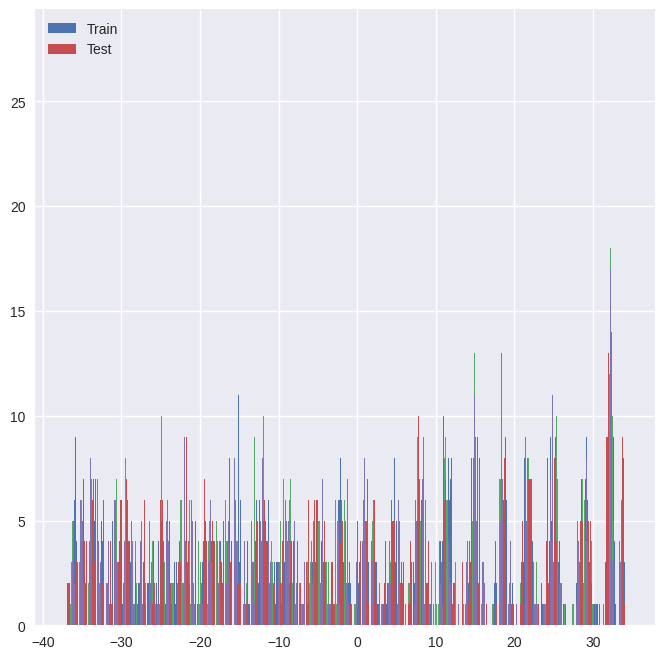

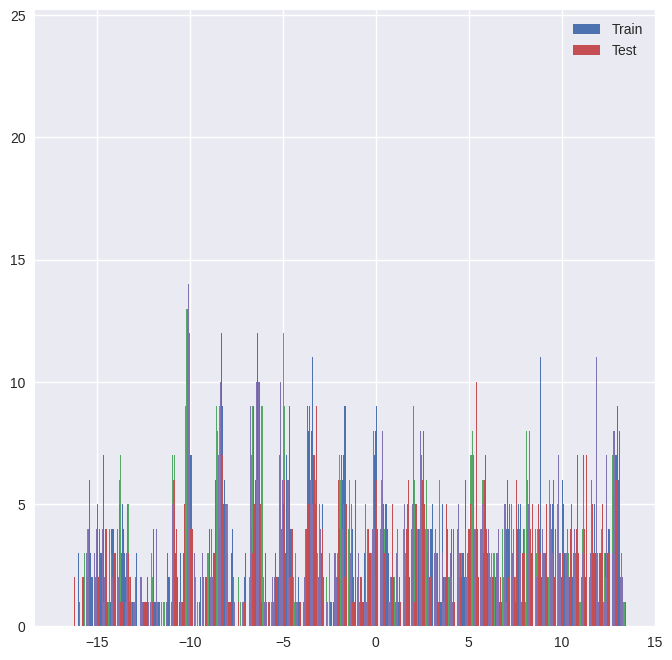

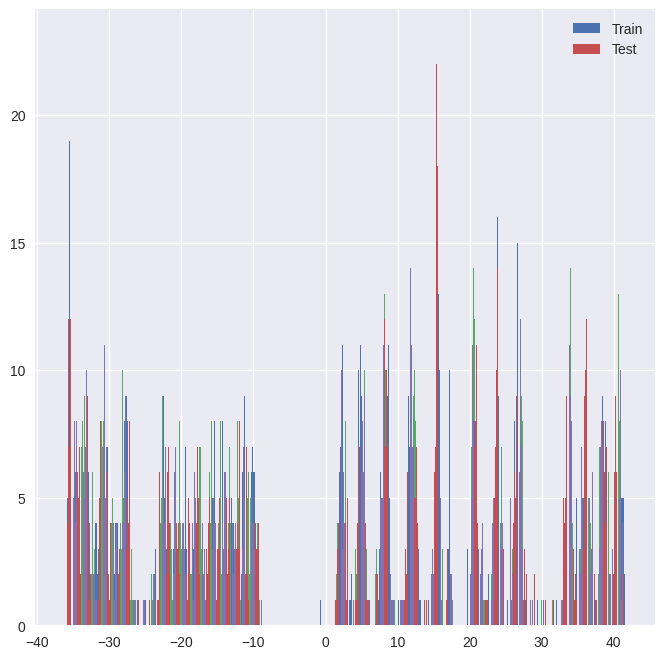

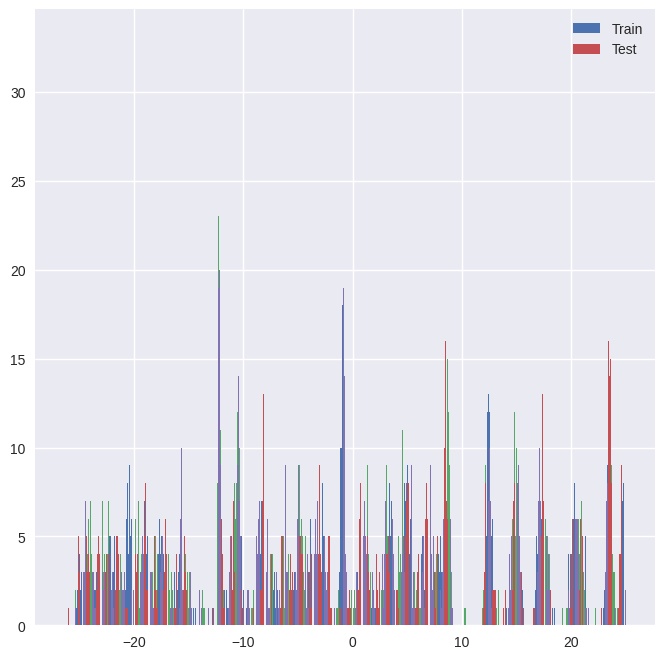

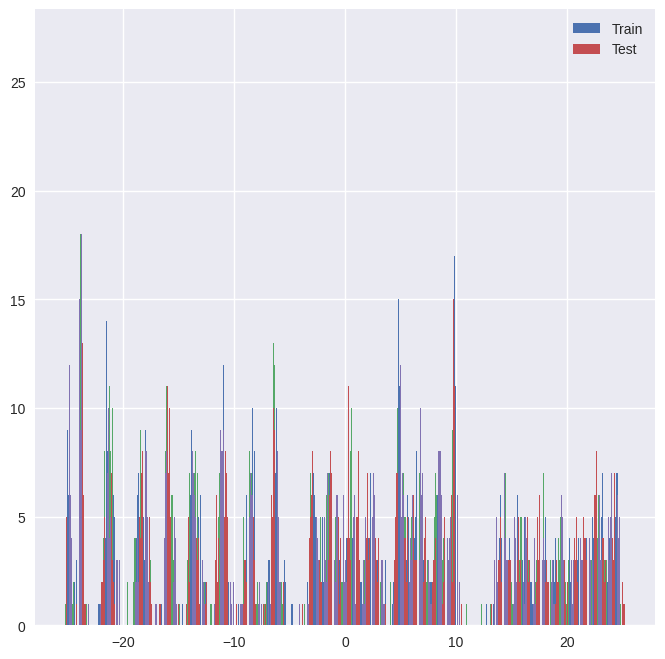

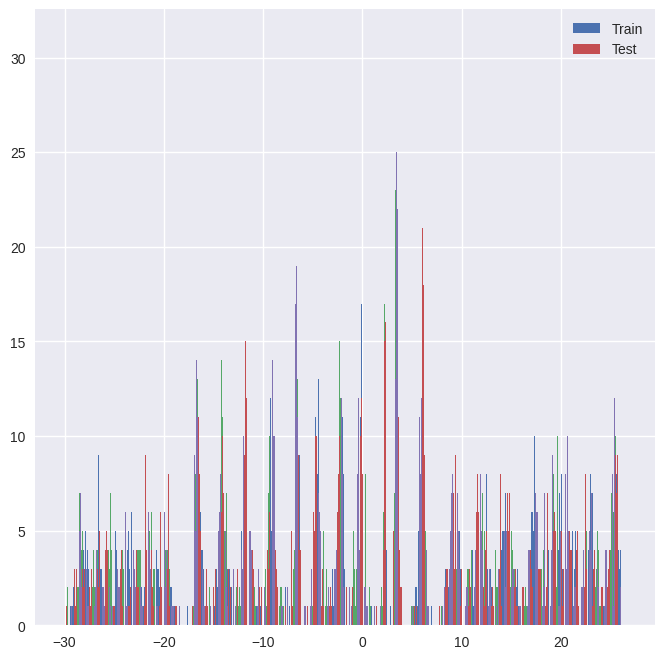

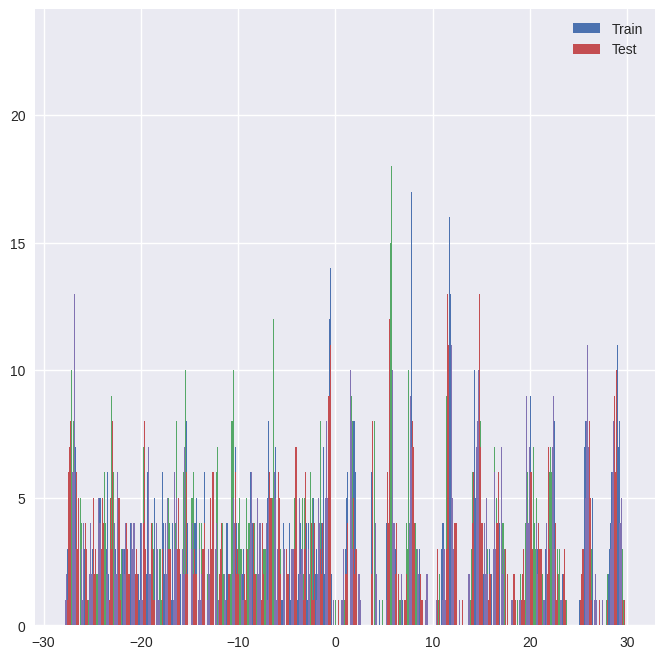

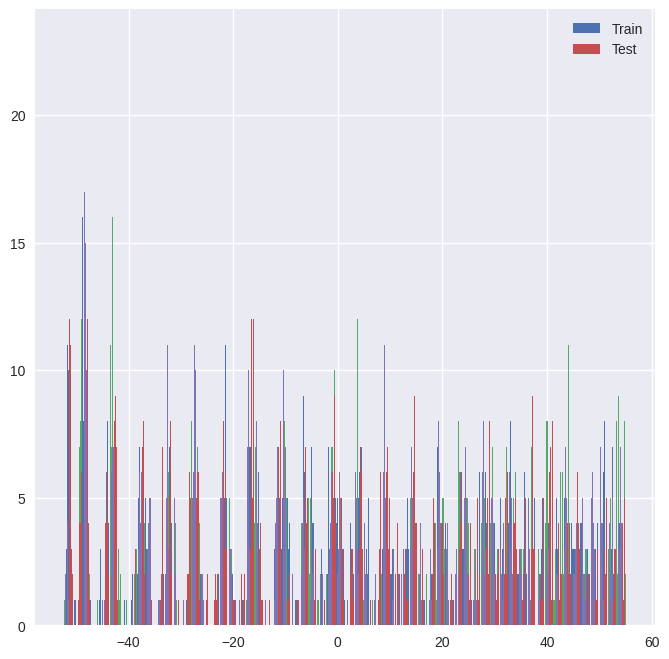

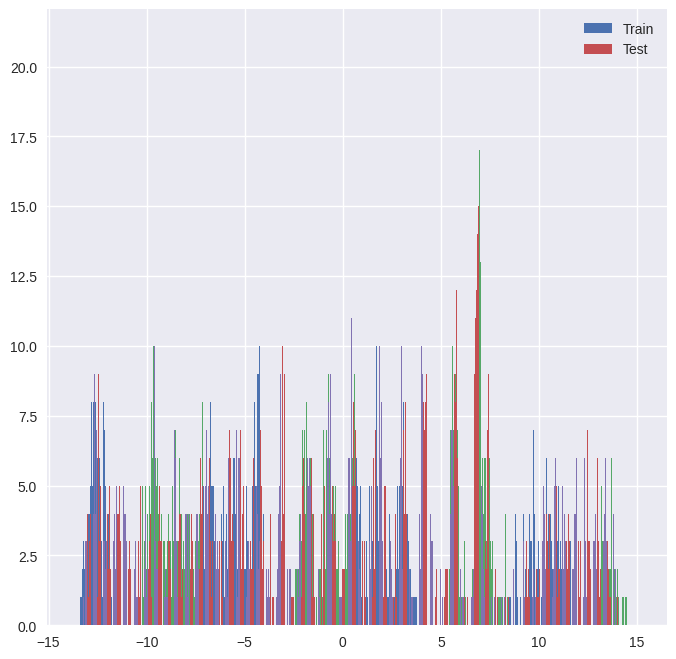

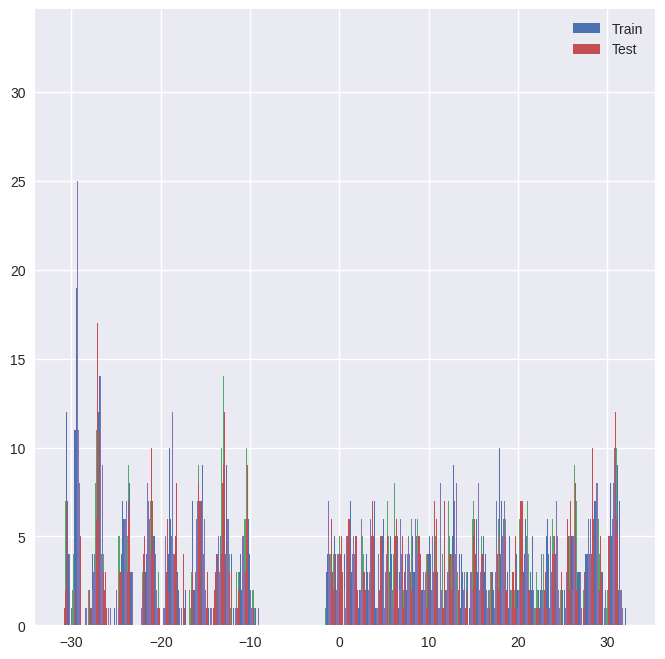

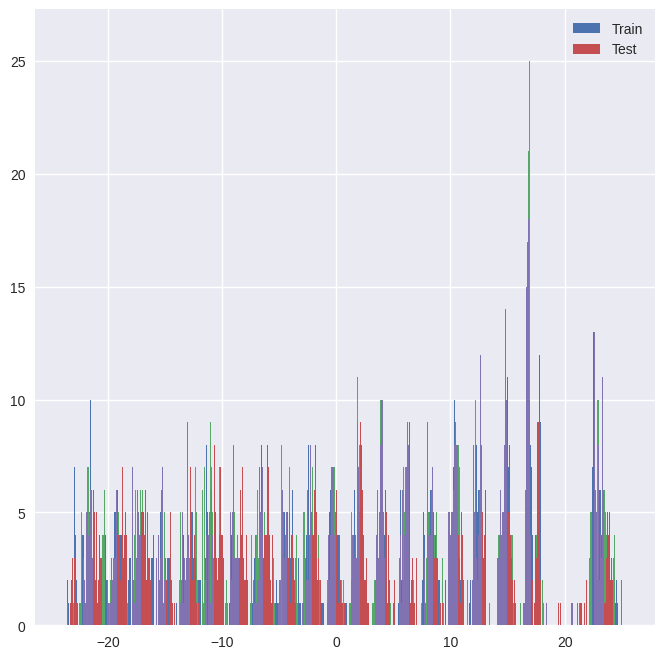

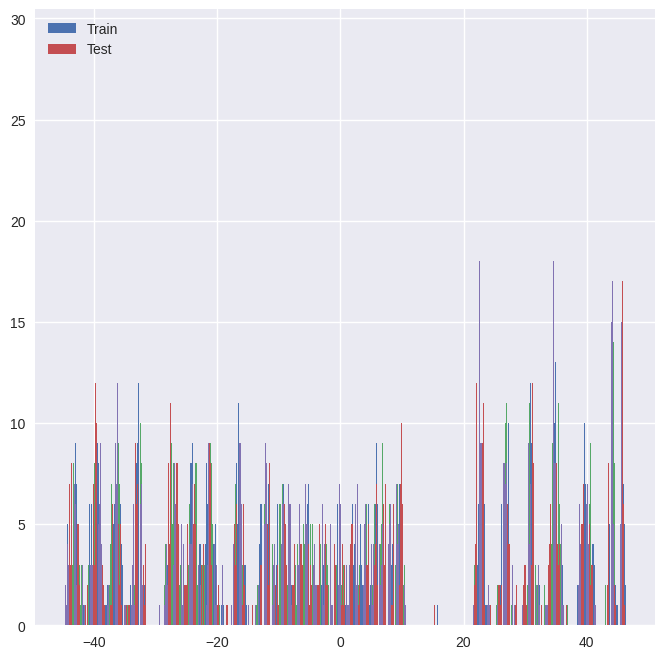

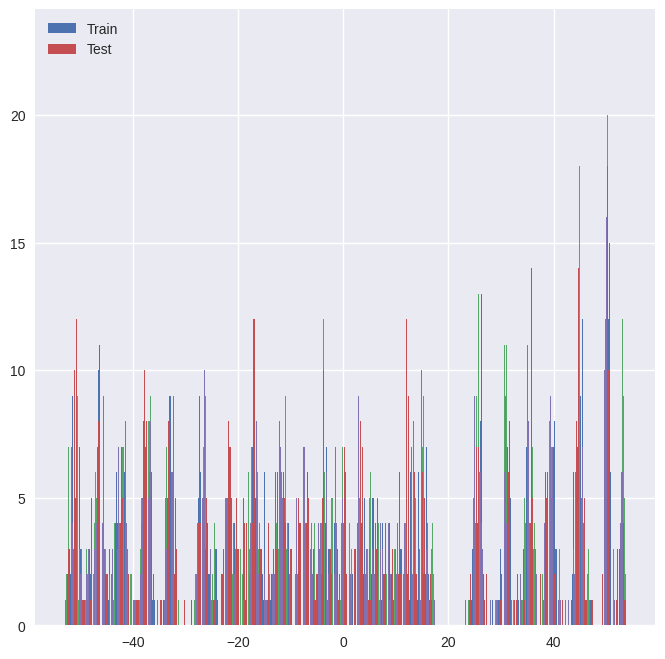

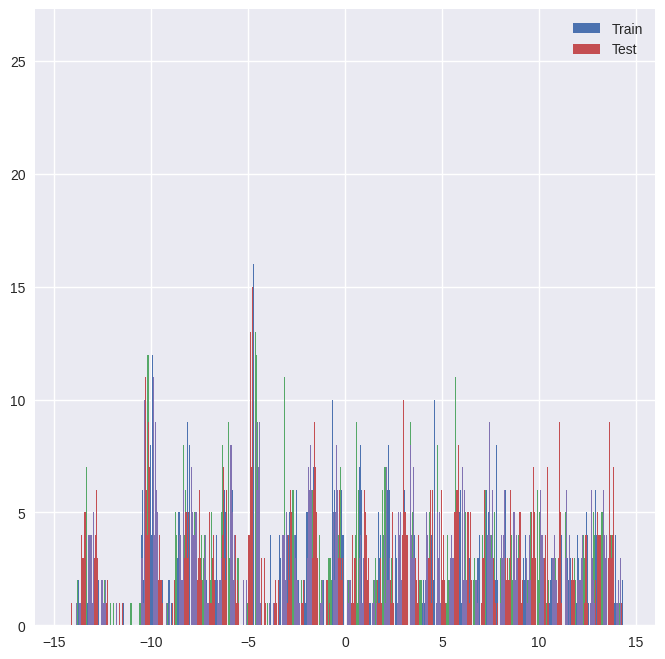

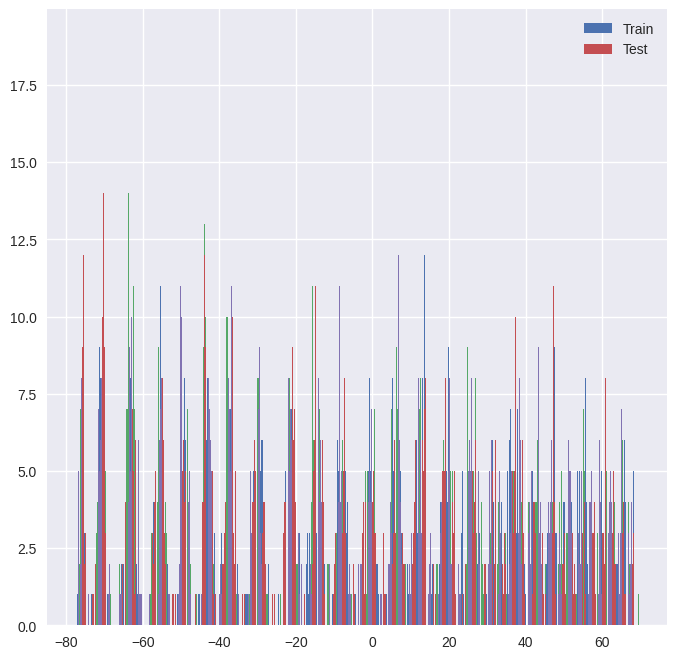

: 

In [ ]:
for file_ in os.listdir(f'runs/{run}/models'):

    loaded_model = torch.load(f'runs/{run}/models/{file_}')

    with plt.style.context("seaborn-v0_8"):
        plot_embs(loaded_model, data_train_, data_test_)